In [1]:
import numpy as np # linear algebra
import pandas as pd 

In [2]:
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv('iris.data.csv', header=None, names=column_names)

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoder = LabelEncoder()

In [8]:
df['species'] = encoder.fit_transform(df['species'])

In [9]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [12]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

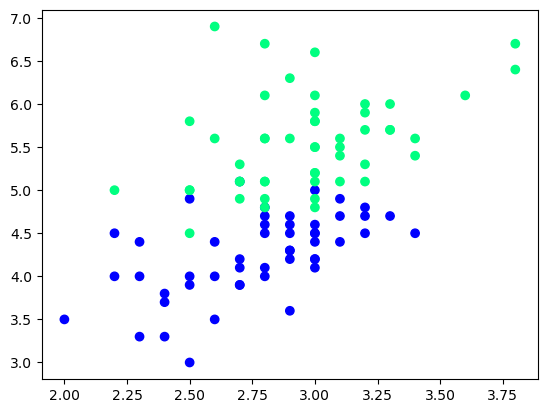

In [15]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [21]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [22]:
df

,sepal_width,petal_length,species
51,3.2,4.5,1
97,2.9,4.3,1
93,2.3,3.3,1
78,2.9,4.5,1
84,3.0,4.5,1
...,...,...,...
61,3.0,4.2,1
77,3.0,5.0,1
95,3.0,4.2,1
68,2.2,4.5,1


In [23]:
df_train

,sepal_width,petal_length,species
114,2.8,5.1,2
96,2.9,4.2,1
53,2.3,4.0,1
139,3.1,5.4,2
72,2.5,4.9,1
110,3.2,5.1,2
125,3.2,6.0,2
82,2.7,3.9,1
104,3.0,5.8,2
73,2.8,4.7,1


In [24]:
df_val

,sepal_width,petal_length,species
132,2.8,5.6,2
102,3.0,5.9,2
140,3.1,5.6,2
124,3.3,5.7,2
55,2.8,4.5,1


In [25]:
df_test

,sepal_width,petal_length,species
64,2.9,3.6,1
136,3.4,5.6,2
128,2.8,5.6,2
108,2.5,5.8,2
91,3.0,4.6,1


In [26]:
X_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

In [27]:
X_test

array([[2.8, 5.6],
       [3. , 5.9],
       [3.1, 5.6],
       [3.3, 5.7],
       [2.8, 4.5]])

In [28]:
y_test

array([2, 2, 2, 2, 1])

CASE 1 - BAGGING

In [29]:
#data for tree 1
df_bag=df_train.sample(8,replace=True)

X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

In [30]:
df_bag

,sepal_width,petal_length,species
53,2.3,4.0,1
96,2.9,4.2,1
53,2.3,4.0,1
72,2.5,4.9,1
114,2.8,5.1,2
104,3.0,5.8,2
53,2.3,4.0,1
72,2.5,4.9,1


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [32]:
dt_bag1 = DecisionTreeClassifier()

In [41]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

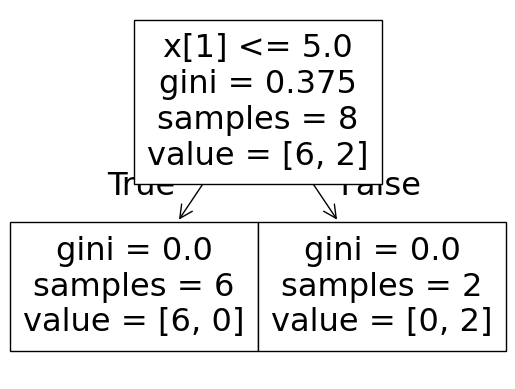

1.0


C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


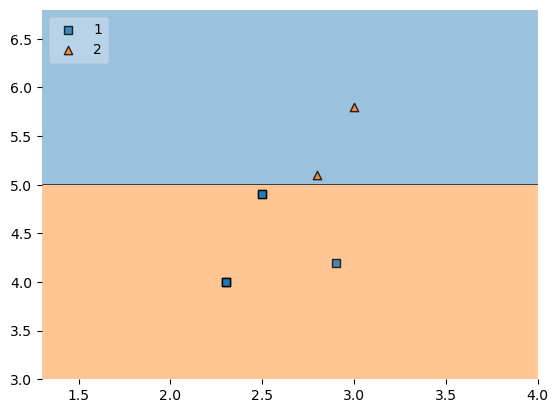

In [42]:
evaluate(dt_bag1,X,y)

In [43]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
139,3.1,5.4,2
110,3.2,5.1,2
72,2.5,4.9,1
82,2.7,3.9,1
139,3.1,5.4,2
73,2.8,4.7,1
110,3.2,5.1,2
104,3.0,5.8,2


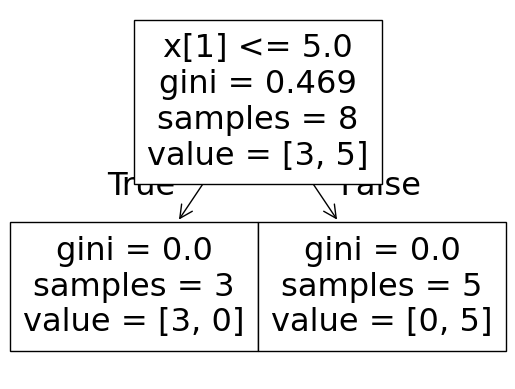

1.0


C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


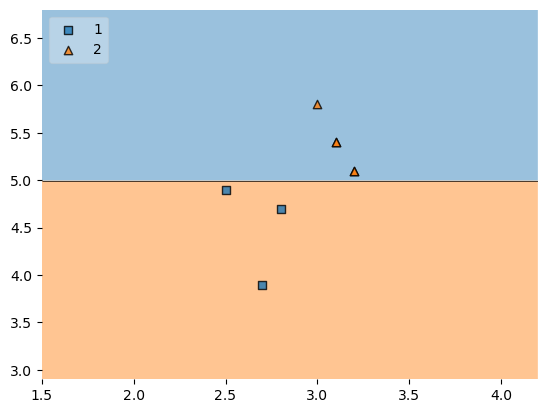

In [44]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [46]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
82,2.7,3.9,1
114,2.8,5.1,2
110,3.2,5.1,2
104,3.0,5.8,2
114,2.8,5.1,2
96,2.9,4.2,1
73,2.8,4.7,1
139,3.1,5.4,2


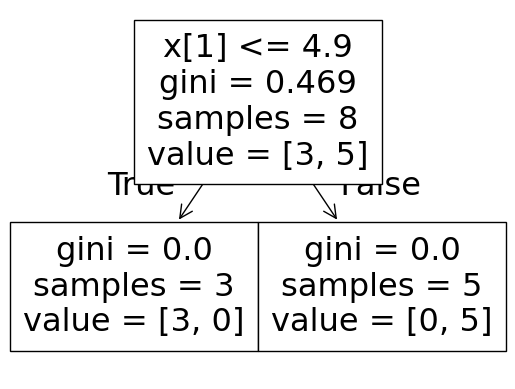

1.0


C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


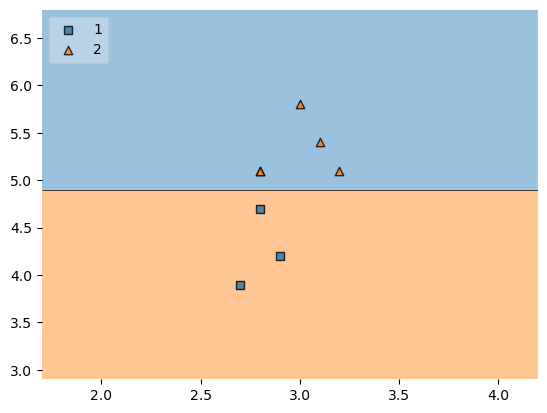

In [47]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

PREDICT

In [48]:
df_test

,sepal_width,petal_length,species
64,2.9,3.6,1
136,3.4,5.6,2
128,2.8,5.6,2
108,2.5,5.8,2
91,3.0,4.6,1


In [51]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [2]


C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
